### Load libraries

In [1]:
from importlib import reload
from helpers import *
from helpers.portfolio import *
import pandas as pd

from helpers.clustering import cluster_select_representatives_from_csv, visualize_clusters
from helpers.fetch import load_data
import pandas as pd

### Clustering

Found 68 tickers across 10 clusters


/Users/giacomomaggiore/Desktop/coding/leverage-api-api/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/giacomomaggiore/Desktop/coding/leverage-api-api/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


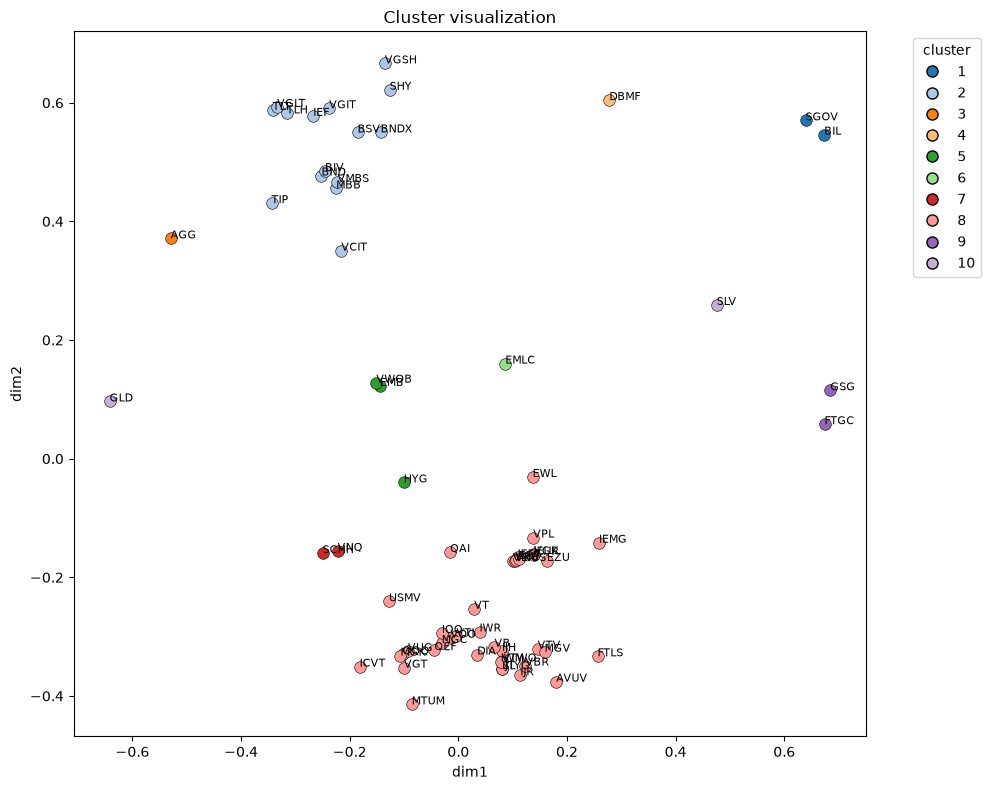

In [2]:
ETF_UNIVERSE_CSV_PATH = "data/etf_universe.csv"

# get clusters (and representatives) from the universe CSV
selected_tickers, clusters = cluster_select_representatives_from_csv(ETF_UNIVERSE_CSV_PATH, n_clusters=10)

print('Found', sum(len(v) for v in clusters.values()), 'tickers across', len(clusters), 'clusters')

# Build aligned price matrix for all tickers in the clusters (inner join on dates)
tickers = sorted([t for members in clusters.values() for t in members])
start_date = '2012-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
prices = pd.concat([load_data(t, start_date, end_date)['adj close'].rename(t) for t in tickers], axis=1, join='inner')
returns = prices.pct_change().dropna()

# Visualize clusters using the returns correlation (MDS embedding)
fig, ax = visualize_clusters(clusters, returns=returns)


### Common window / Optimization / Portfolio construction using the tickers from the clustering

In [3]:
# common window for selected_tickers tickers

min_window, max_window = common_window(selected_tickers)

start_date = "2012-01-01"
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")

print("Min common start date:", min_window, "Max common end date:", max_window)
    
portfolios = build_portfolios(selected_tickers, start_date, end_date)


Min common start date: 2020-06-01 00:00:00 Max common end date: 2026-07-09 00:00:00


### Backtest with historical data using the weights given by optimization 

- min_variance
- equal_weights
- max_sharpie
- market_cap

In [4]:
# Backtest with historical data (min-variance, max-sharpe, market-cap (VT), equal-weight)
from helpers.backtest import backtest_portfolio

# compute portfolio value series for each strategy
min_variance = backtest_portfolio(portfolios["min_variance"], start_value=10_000.0)
max_sharpe  = backtest_portfolio(portfolios["max_sharpe"],  start_value=10_000.0)
market_cap  = backtest_portfolio(portfolios["market_cap"],  start_value=10_000.0)
equal_weight = backtest_portfolio(portfolios["equal_weight"], start_value=10_000.0)

# merge into a single DataFrame for comparison
backtest_results = pd.concat(
    [
        min_variance.rename("min_variance"),
        max_sharpe.rename("max_sharpe"),
        market_cap.rename("market_cap"),
        equal_weight.rename("equal_weight"),
    ],
    axis=1,
)
backtest_results

,min_variance,max_sharpe,market_cap,equal_weight
date,,,,
2020-07-02,10012.773613,10034.437900,10000.0,10027.315265
2020-07-06,10024.487054,10070.079926,10000.0,10069.426850
2020-07-07,10033.116766,10089.181318,10000.0,10040.350536
2020-07-08,10038.464952,10132.814798,10000.0,10075.019611
2020-07-09,10053.642706,10102.292188,10000.0,10056.213941
...,...,...,...,...
2026-04-20,11752.827469,15280.063193,10000.0,16406.167648
2026-07-06,11802.360315,15318.976850,10000.0,16197.859774
2026-07-07,11800.483868,15316.532798,10000.0,16204.919067


### Montecarlo parametric simulation

In [5]:
# Monte Carlo (parametric): simulate returns, rebuild weights, backtest
from helpers.montecarlo import simulate_parametric, rebalance_on_simulation

# simulate ~1 year of daily returns for current tickers
tickers = list(portfolios["min_variance"].columns)
sims_param = simulate_parametric(tickers, n_days=252, n_sims=1, lookback_years=3, seed=42)

# rebuild weights on simulated prices and backtest
W_param, V_param = rebalance_on_simulation(
    sims_param[0], lookback_years=4, freq="BMS", which="min_variance", start_value=10_000.0
)
W_param

,AGG,BND,DBMF,EMLC,GLD,GSG,HYG,SGOV,VNQ,VOO,VT
2000-02-01,0.11895,0.13742,0.17540,0.15766,0.02509,0.03012,0.09630,0.25453,0.0,0.0,0.00453
2000-02-02,0.11895,0.13742,0.17540,0.15766,0.02509,0.03012,0.09630,0.25453,0.0,0.0,0.00453
2000-02-03,0.11895,0.13742,0.17540,0.15766,0.02509,0.03012,0.09630,0.25453,0.0,0.0,0.00453
2000-02-04,0.11895,0.13742,0.17540,0.15766,0.02509,0.03012,0.09630,0.25453,0.0,0.0,0.00453
2000-02-07,0.11895,0.13742,0.17540,0.15766,0.02509,0.03012,0.09630,0.25453,0.0,0.0,0.00453
...,...,...,...,...,...,...,...,...,...,...,...
2000-12-13,0.05632,0.05740,0.04568,0.02566,0.00433,0.00930,0.02267,0.77863,0.0,0.0,0.00000
2000-12-14,0.05632,0.05740,0.04568,0.02566,0.00433,0.00930,0.02267,0.77863,0.0,0.0,0.00000
2000-12-15,0.05632,0.05740,0.04568,0.02566,0.00433,0.00930,0.02267,0.77863,0.0,0.0,0.00000
2000-12-18,0.05632,0.05740,0.04568,0.02566,0.00433,0.00930,0.02267,0.77863,0.0,0.0,0.00000


## Montecarlo Bootstrap

In [6]:
# Monte Carlo (bootstrap): moving-block bootstrap, rebuild weights, backtest
from helpers.montecarlo import simulate_bootstrap, rebalance_on_simulation

sims_boot = simulate_bootstrap(
    tickers, n_days=252, n_sims=3, lookback_years=3, block_size=10, seed=1
)
W_boot, V_boot = rebalance_on_simulation(
    sims_boot[0], lookback_years=4, freq="BMS", which="min_variance", start_value=10_000.0
)

W_boot

,AGG,BND,DBMF,EMLC,GLD,GSG,HYG,SGOV,VNQ,VOO,VT
2000-02-01,0.11100,0.12625,0.07930,0.00726,0.0,0.07195,0.19886,0.33455,0.0,0.04639,0.02445
2000-02-02,0.11100,0.12625,0.07930,0.00726,0.0,0.07195,0.19886,0.33455,0.0,0.04639,0.02445
2000-02-03,0.11100,0.12625,0.07930,0.00726,0.0,0.07195,0.19886,0.33455,0.0,0.04639,0.02445
2000-02-04,0.11100,0.12625,0.07930,0.00726,0.0,0.07195,0.19886,0.33455,0.0,0.04639,0.02445
2000-02-07,0.11100,0.12625,0.07930,0.00726,0.0,0.07195,0.19886,0.33455,0.0,0.04639,0.02445
...,...,...,...,...,...,...,...,...,...,...,...
2000-12-13,0.03021,0.08140,0.04098,0.00000,0.0,0.01045,0.08275,0.75422,0.0,0.00000,0.00000
2000-12-14,0.03021,0.08140,0.04098,0.00000,0.0,0.01045,0.08275,0.75422,0.0,0.00000,0.00000
2000-12-15,0.03021,0.08140,0.04098,0.00000,0.0,0.01045,0.08275,0.75422,0.0,0.00000,0.00000
2000-12-18,0.03021,0.08140,0.04098,0.00000,0.0,0.01045,0.08275,0.75422,0.0,0.00000,0.00000


## Montecarlo aggregation and exporting

In [7]:
from pathlib import Path
from helpers.montecarlo import simulate_and_backtest_portfolios, save_simulations_parquet

# use a local writable path
out_path = Path("output/mc_values.parquet")

df = simulate_and_backtest_portfolios(
    tickers=selected_tickers,
    n_days=252,
    n_sims=10,
    lookback_years=3,
    block_size=10,
    seed=1,
    method="bootstrap",
)
save_simulations_parquet(df, str(out_path), engine="fastparquet")

# round-trip check is in the next cell

In [ ]:
save_simulations_parquet(df, str(out_path), engine="pyarrow")
df_loaded = pd.read_parquet(out_path, engine="pyarrow")



In [13]:
df_loaded

sim                    1                                                    2  \
strategy    min_variance    max_sharpe  equal_weight market_cap  min_variance   
date                                                                            
2000-01-03  10000.000000  10000.000000  10000.000000    10000.0  10000.000000   
2000-01-04  10000.000000  10000.000000  10000.000000    10000.0  10000.000000   
2000-01-05  10000.000000  10000.000000  10000.000000    10000.0  10000.000000   
2000-01-06  10000.000000  10000.000000  10000.000000    10000.0  10000.000000   
2000-01-07  10000.000000  10000.000000  10000.000000    10000.0  10000.000000   
...                  ...           ...           ...        ...           ...   
2000-12-13  10497.917296  10711.188620  10951.096774    10000.0  10624.324383   
2000-12-14  10494.950223  10705.623761  10859.114611    10000.0  10623.232251   
2000-12-15  10495.123760  10716.264416  10869.542104    10000.0  10625.491991   
2000-12-18  10508.658637  10740.306885  10922.567775    10000.0  10624.405502   
2000-12-19  10510.066449  10756.464336  10951.787650    10000.0  10623.979160   

sim                                                           3                \
strategy      max_sharpe  equal_weight market_cap  min_variance    max_sharpe   
date                                                                            
2000-01-03  10000.000000  10000.000000    10000.0  10000.000000  10000.000000   
2000-01-04  10000.000000  10000.000000    10000.0  10000.000000  10000.000000   
2000-01-05  10000.000000  10000.000000    10000.0  10000.000000  10000.000000   
2000-01-06  10000.000000  10000.000000    10000.0  10000.000000  10000.000000   
2000-01-07  10000.000000  10000.000000    10000.0  10000.000000  10000.000000   
...                  ...           ...        ...           ...           ...   
2000-12-13  11523.764619  11783.032154    10000.0  10408.195157  10136.380830   
2000-12-14  11524.567306  11764.562454    10000.0  10409.183793  10138.172238   
2000-12-15  11504.387945  11737.381634    10000.0  10411.277546  10141.045343   
2000-12-18  11503.737128  11738.586052    10000.0  10417.499295  10152.394517   
2000-12-19  11512.742752  11749.304173    10000.0  10416.249753  10152.663529   

sim         ...             8                        9                \
strategy    ...  equal_weight market_cap  min_variance    max_sharpe   
date        ...                                                        
2000-01-03  ...  10000.000000    10000.0  10000.000000  10000.000000   
2000-01-04  ...  10000.000000    10000.0  10000.000000  10000.000000   
2000-01-05  ...  10000.000000    10000.0  10000.000000  10000.000000   
2000-01-06  ...  10000.000000    10000.0  10000.000000  10000.000000   
2000-01-07  ...  10000.000000    10000.0  10000.000000  10000.000000   
...         ...           ...        ...           ...           ...   
2000-12-13  ...  12353.064515    10000.0  10258.957898  10121.837768   
2000-12-14  ...  12344.227683    10000.0  10263.235332  10114.626885   
2000-12-15  ...  12317.024929    10000.0  10271.125400  10109.429439   
2000-12-18  ...  12168.922159    10000.0  10266.962071  10098.111865   
2000-12-19  ...  12081.811137    10000.0  10256.166851  10077.160482   

sim                                            10                              \
strategy    equal_weight market_cap  min_variance    max_sharpe  equal_weight   
date                                                                            
2000-01-03  10000.000000    10000.0  10000.000000  10000.000000  10000.000000   
2000-01-04  10000.000000    10000.0  10000.000000  10000.000000  10000.000000   
2000-01-05  10000.000000    10000.0  10000.000000  10000.000000  10000.000000   
2000-01-06  10000.000000    10000.0  10000.000000  10000.000000  10000.000000   
2000-01-07  10000.000000    10000.0  10000.000000  10000.000000  10000.000000   
...                  ...        ...           ...           ...          

In [ ]:
# single column (one sim, one strategy) -> Series of portfolio value over time
df[(1, "min_variance")]

# same, via .loc
df.loc[:, (1, "min_variance")]

# all strategies for one sim -> sub-DataFrame, columns become just "strategy"
df[1]                       # or df.xs(1, level="sim", axis=1)

# one strategy across all sims -> sub-DataFrame, columns become just "sim"
df.xs("min_variance", level="strategy", axis=1)

# the full "horizon" (all dates) for one sim/strategy path is just the Series itself
df[(1, "min_variance")].plot()

# slice a date range on any of the above
df.loc["2000-06-01":"2000-09-01", (1, "min_variance")]


date
2000-01-03    10000.000000
2000-01-04    10000.000000
2000-01-05    10000.000000
2000-01-06    10000.000000
2000-01-07    10000.000000
                  ...     
2000-12-13    10497.917296
2000-12-14    10494.950223
2000-12-15    10495.123760
2000-12-18    10508.658637
2000-12-19    10510.066449
Freq: B, Name: (1, min_variance), Length: 252, dtype: float64

In [ ]:
df.loc[:, (1, "min_variance")]


[Docs](https://pyportfolioopt.readthedocs.io/en/stable/index.html)